In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from datetime import datetime, timedelta
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from python_scripts.math_utils import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


### Simulate SGR dataset with beta distributions mixture

In [2]:
df = simulate_SGR_dataset(n=10000)
df

,y_true,y_pred,SR
0,0,0.0,0.994084
1,1,1.0,0.972204
2,0,0.0,0.763839
3,0,0.0,0.977806
4,0,1.0,0.380255
...,...,...,...
9995,1,1.0,0.837544
9996,0,0.0,0.956362
9997,1,1.0,0.758735
9998,1,1.0,0.819119


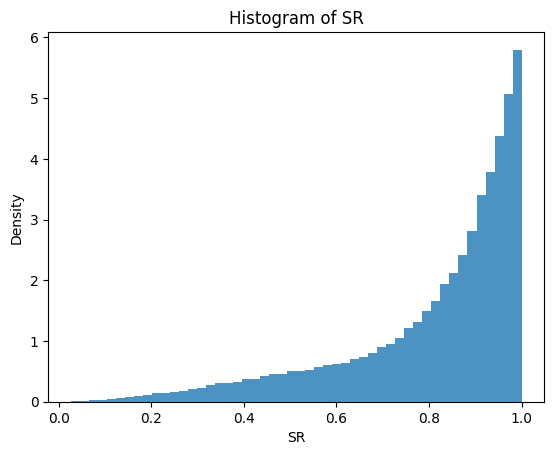

In [21]:
plt.hist(df['SR'], bins=50, density=True, alpha=0.8)
plt.title("Histogram of SR")
plt.xlabel("SR")
plt.ylabel("Density")
plt.show()

C:\Users\Emilien JEMELEN\AppData\Local\Temp\ipykernel_19936\962436781.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mistakes_by_SR = df.groupby(pd.cut(df['SR'], bins=np.linspace(0, 1, 11)))['y_true'].apply(lambda x: (x != df.loc[x.index, 'y_pred']).mean())


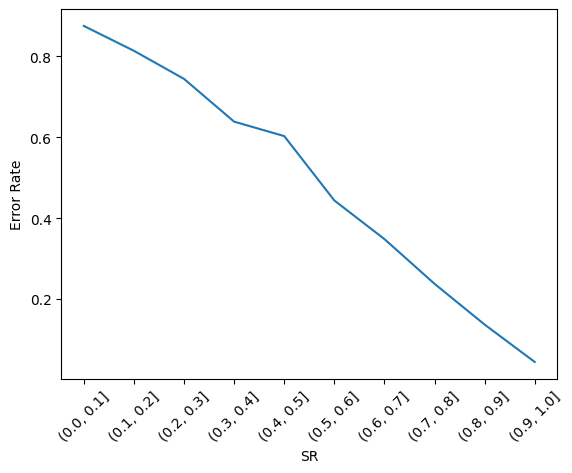

In [4]:
mistakes_by_SR = df.groupby(pd.cut(df['SR'], bins=np.linspace(0, 1, 11)))['y_true'].apply(lambda x: (x != df.loc[x.index, 'y_pred']).mean())
plt.plot(mistakes_by_SR.index.astype(str), mistakes_by_SR)
plt.xlabel("SR")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.show()

### Evolution with n of time to run SGR_at_targets with dichotomy search, greedy_search(steps=10,20,50)

In [11]:
dicos = []

for n in [10000*i for i in range(1,11)]:
    
    df = simulate_SGR_dataset(n=n)
    
    t0 = datetime.now()
    res = SGR_dicho(delta=1e-3, r_star=0.05, Sm=df, k=int(np.log2(df.shape[0])), metric='standard', tolerance=1e-3, union=False)
    t1 = datetime.now()
    dicos.append({'Search mode' : 'Dichotomy', 'n' : n, 'Runtime' : (t1-t0).seconds})

    for steps in [10, 20, 50]:
        t0 = datetime.now()
        res = SGR_greedy_search(delta=1e-3, r_star=0.05, Sm=df, metric='standard', steps=steps)
        t1 = datetime.now()
        dicos.append({'Search mode': 'Greedy_'+str(steps)+'_steps', 'n': n, 'Runtime' : (t1-t0).seconds})

In [15]:
times = pd.DataFrame(dicos)
times

,Search mode,n,Runtime
0,Dichotomy,10000,0
1,Greedy_10_steps,10000,1
2,Greedy_20_steps,10000,4
3,Greedy_50_steps,10000,10
4,Dichotomy,20000,3
5,Greedy_10_steps,20000,4
6,Greedy_20_steps,20000,8
7,Greedy_50_steps,20000,24
8,Dichotomy,30000,3
9,Greedy_10_steps,30000,6


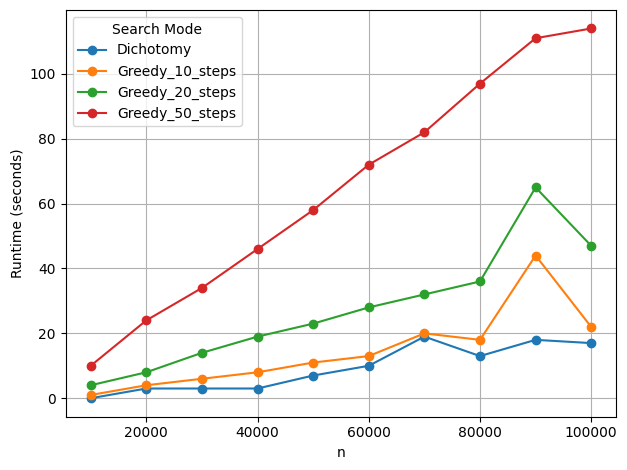

In [18]:
# Pivot the data for easier plotting
pivot_df = times.pivot(index='n', columns='Search mode', values='Runtime')

# Plotting
pivot_df.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Runtime (seconds)')
plt.grid(True)
plt.legend(title='Search Mode')
plt.tight_layout()
plt.show()